In [1]:
import numpy as np
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur, ExponentialConvolution
from regpy.vecsps import UniformGridFcts
from regpy.solvers import TikhonovRegularizationSetting, RegularizationSetting, RegSolver
from regpy.solvers.linear.semismoothNewton import SemismoothNewton_bilateral, SemismoothNewton_nonneg, SemismoothNewtonAlphaGrid
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.primal_dual import PDHG
from regpy.solvers.linear.proximal_gradient import FISTA
import regpy.functionals as fct
from regpy.hilbert import L2
from regpy.stoprules import CountIterations
from comparison_plot import comparison_plot
import logging

# Generate a test image as exact solution

In [2]:
grid = UniformGridFcts((-1, 1, 256), (-1.5, 1, 256),dtype = float, periodic = True)
"""Space of real-valued functions on a uniform grid with rectangular pixels"""
X = grid.coords[0]; Y = grid.coords[1]
"""x and y coordinates."""
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(X**2 + Y**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.925)
smallbox = (abs(X+0.55)<=0.05) * (abs(Y-0.55)<=0.05)
bubbles = (1.001+np.sin(50/(X+1.3)))*np.exp(-((Y+1.25)/0.1)**2)*(X>-0.8)*(X<0.8)

ramp = Y<=-1

objects = 50*(ring + 2.0*cross + 1.5*smallbox + 2*ramp -bubbles)
exact_sol = objects 


# Generate synthetic data with impulsive noise

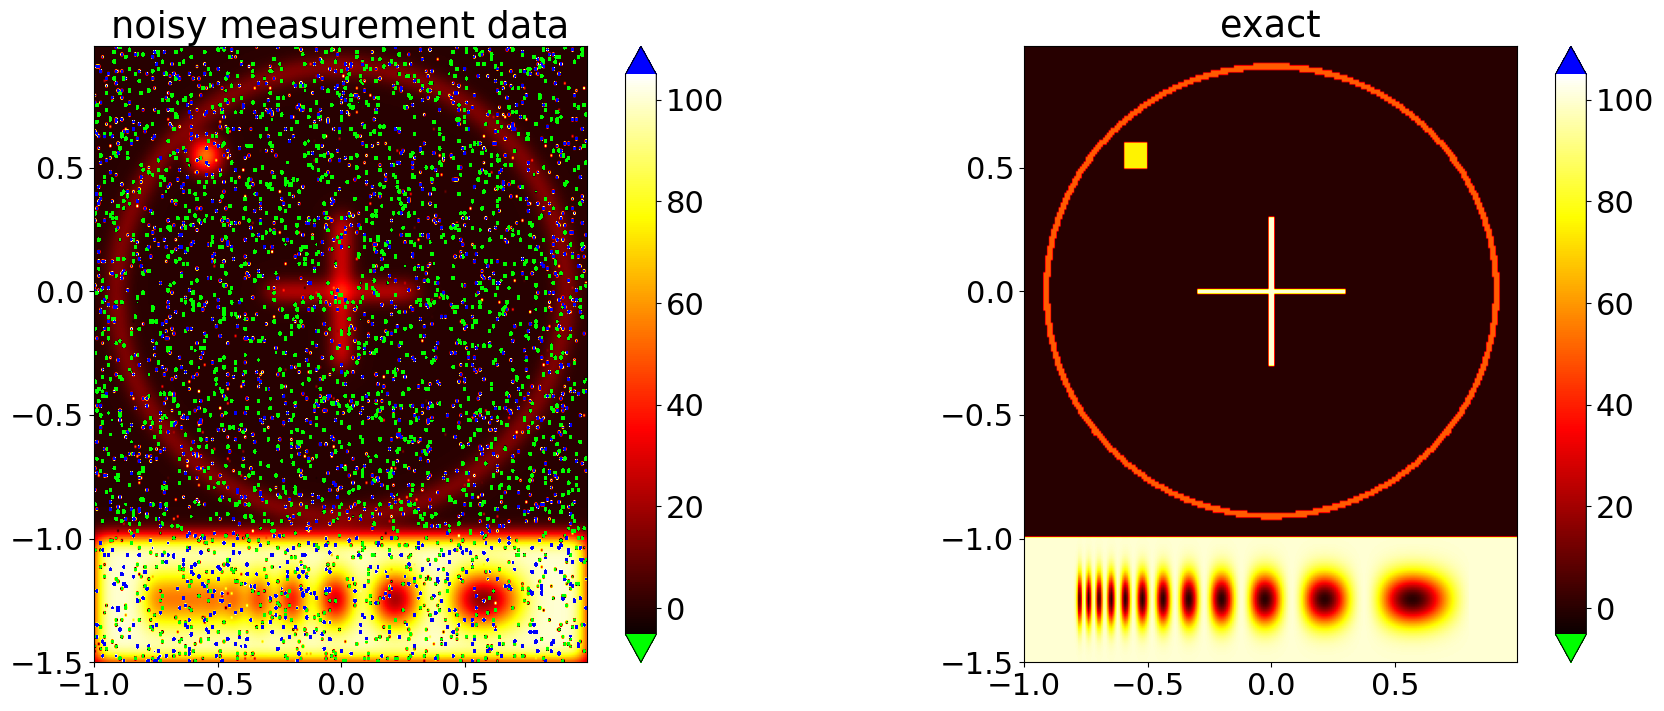

In [3]:
a=0.05
conv =  GaussianBlur(grid,a,pad_amount=((16,16),(16,16)))
"""Convolution operator \(f\mapsto h*f\) for the convolution kernel \(h(x)=\exp(-|x|_2^2/a^2)\)."""
blur = conv(exact_sol)
blur[blur<0] = 0.
data = blur.copy()
n,m=grid.shape
for j in range(64**2):
    nn = np.random.randint(n)
    mm = np.random.randint(m)
    data[nn,mm] =  np.random.randint(2000)-1000

comparison_plot(grid,exact_sol,data,title_left='noisy measurement data')

# Reconstruction with a quadratic data fidelity term

2024-06-29 18:20:44,544 INFO TikhonovCG           :: it.76 kappa=2.882803336117683 err/Tol rel X:9.2e-07/1.0e-06 
2024-06-29 18:20:44,545 INFO TikhonovCG           :: Solver converged after 76 iteration.


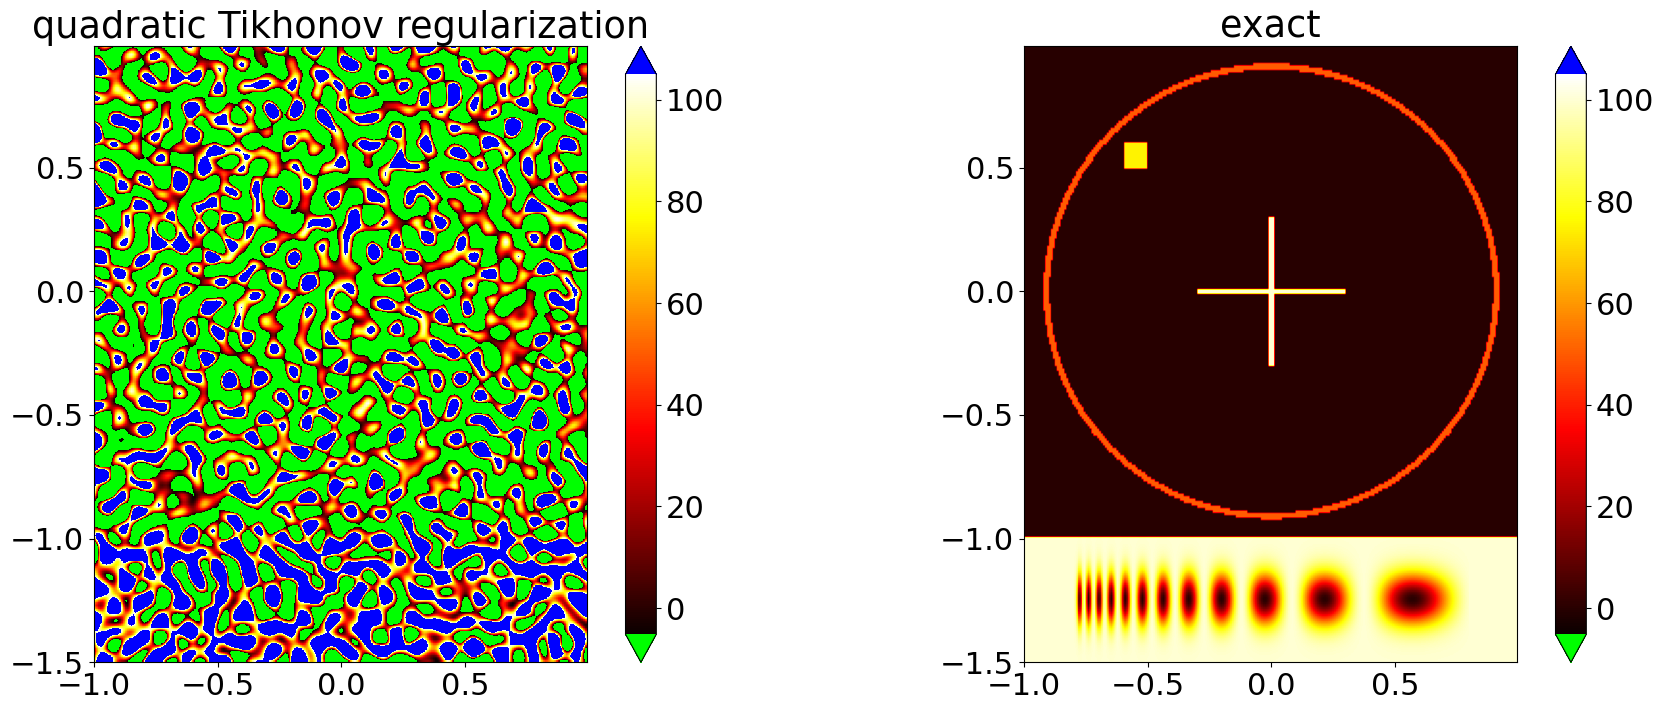

In [4]:
sigma = 10.
alpha = 0.01
setting = RegularizationSetting(conv,L2,L2)
solver = TikhonovCG(setting=setting, data = data, regpar = alpha,reltolx=1e-6)
fal,_ = solver.run()

comparison_plot(grid,exact_sol,fal,title_left='quadratic Tikhonov regularization')

# setting with Huber data fidelity term
We now set up a generalized Tikhonov regularization setting
$$
\hat{f} \in \mathrm{argmin}_f\left[\frac{1}{\alpha}H_{\sigma}(Tf-g^{\mathrm{obs}})+\|f\|^2\right]    
$$
where the Huber data fidelity term $H_{\sigma}$ is quadratic on coordinates in $[-\sigma,\sigma]$ and $|\cdot|-\sigma/2$ for large coordinates.

Moreover, we set up three solvers for this setting:
- FISTA
- Primal-Dual Hybrid Gradient (Chambolle-Pock) method
- Semismooth Newton method


In [5]:
Sdat = (1./sigma)*fct.Huber(grid,sigma=sigma)
Rfun = fct.QuadraticNonneg(grid)
huber_setting = TikhonovRegularizationSetting(conv,Rfun,Sdat,alpha,data_fid_shift=data)
dual_setting = huber_setting.dualSetting()

solverFISTA = FISTA(dual_setting,logging_level=logging.DEBUG)
solverPDHG = PDHG(huber_setting,logging_level=logging.DEBUG)
itPDHG = iter(solverPDHG)
itFISTA = iter(solverFISTA)

2024-06-29 18:20:46,125 INFO FISTA                :: Set up FISTA with convexity parameters mu_R=1.000e-01, mu_S=0.000e+00 and step length tau=1.011e+00.
 Expected linear convergence rate: 6.970e-01
2024-06-29 18:20:46,165 INFO FISTA                :: initial duality gap: 227.46981822155564
2024-06-29 18:20:47,107 INFO PDHG                 :: Using accelerated version 2 with convexity parameters mu_R=1.000e+00, mu_S*=1.000e-01 and ||T||=9.973e-01.
 Expected linear convergence rate: 6.119e-01


# FISTA
Run this cell until the duality gap is sufficiently small. 

2024-06-29 18:20:47,190 DEBUG FISTA                :: it.1: duality gap=4.650e+00
2024-06-29 18:20:47,237 DEBUG FISTA                :: it.2: duality gap=1.250e+00
2024-06-29 18:20:47,276 DEBUG FISTA                :: it.3: duality gap=4.368e-01
2024-06-29 18:20:47,317 DEBUG FISTA                :: it.4: duality gap=1.830e-01
2024-06-29 18:20:47,368 DEBUG FISTA                :: it.5: duality gap=8.357e-02
2024-06-29 18:20:47,432 DEBUG FISTA                :: it.6: duality gap=3.809e-02
2024-06-29 18:20:47,480 DEBUG FISTA                :: it.7: duality gap=1.814e-02
2024-06-29 18:20:47,524 DEBUG FISTA                :: it.8: duality gap=8.560e-03
2024-06-29 18:20:47,572 DEBUG FISTA                :: it.9: duality gap=4.007e-03
2024-06-29 18:20:47,631 DEBUG FISTA                :: it.10: duality gap=2.011e-03
2024-06-29 18:20:47,681 DEBUG FISTA                :: it.11: duality gap=1.028e-03
2024-06-29 18:20:47,724 DEBUG FISTA                :: it.12: duality gap=5.404e-04
2024-06-29 18

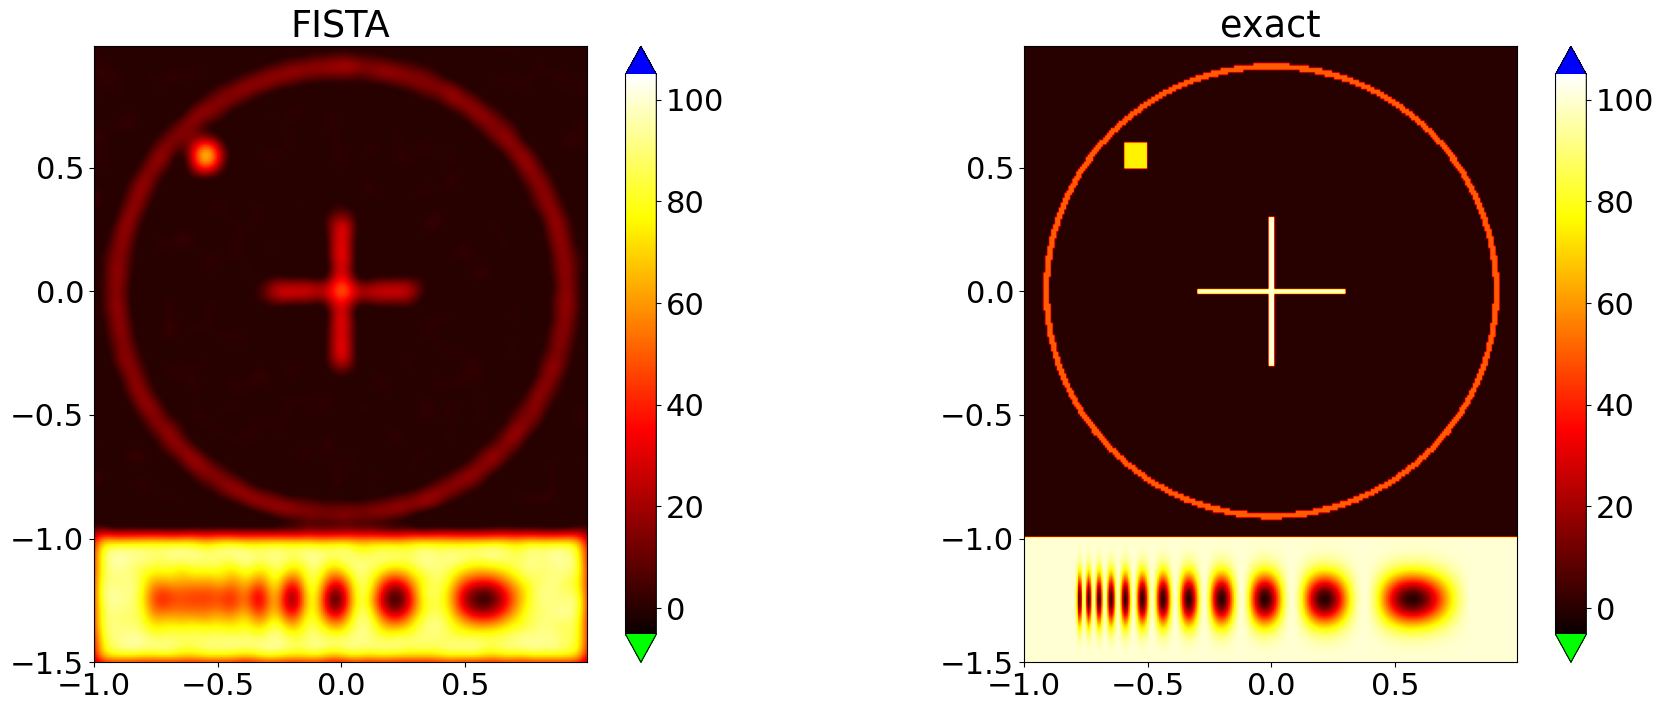

In [6]:
for j in range(20):
    p_FISTA,Tstar_pFISTA = next(itFISTA)
f_FISTA = huber_setting.dualToPrimal(Tstar_pFISTA,argumentIsOperatorImage=True)

comparison_plot(grid,exact_sol,f_FISTA,title_left='FISTA')

# PDHG
Run this cell until the duality gap is sufficiently small. 

2024-06-29 18:20:49,143 DEBUG PDHG                 :: it. 1: duality gap=6.866e+03
2024-06-29 18:20:49,269 DEBUG PDHG                 :: it. 2: duality gap=3.176e+03
2024-06-29 18:20:49,386 DEBUG PDHG                 :: it. 3: duality gap=1.311e+03
2024-06-29 18:20:49,487 DEBUG PDHG                 :: it. 4: duality gap=6.520e+02
2024-06-29 18:20:49,598 DEBUG PDHG                 :: it. 5: duality gap=4.004e+02
2024-06-29 18:20:49,727 DEBUG PDHG                 :: it. 6: duality gap=2.439e+02
2024-06-29 18:20:49,834 DEBUG PDHG                 :: it. 7: duality gap=1.201e+02
2024-06-29 18:20:49,940 DEBUG PDHG                 :: it. 8: duality gap=5.430e+01
2024-06-29 18:20:50,010 DEBUG PDHG                 :: it. 9: duality gap=2.781e+01
2024-06-29 18:20:50,106 DEBUG PDHG                 :: it. 10: duality gap=1.675e+01
2024-06-29 18:20:50,176 DEBUG PDHG                 :: it. 11: duality gap=1.026e+01
2024-06-29 18:20:50,230 DEBUG PDHG                 :: it. 12: duality gap=5.716e+00
2

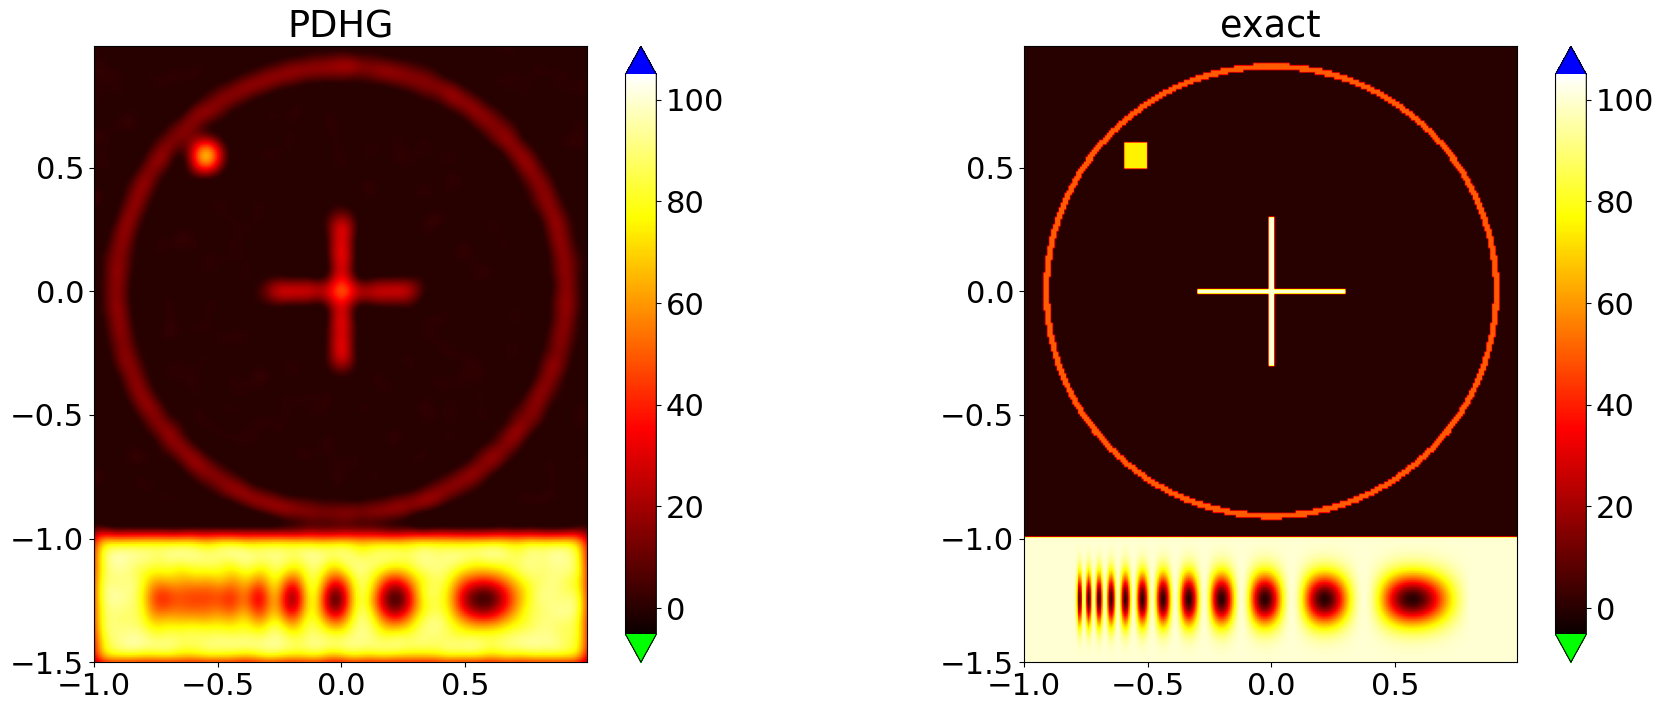

In [7]:
for j in range(20):
    f_PDHG,p_PDHG = next(itPDHG)

comparison_plot(grid,exact_sol,f_PDHG,title_left='PDHG')